# 03 — Prot-T5 Log-Ratio Scores

This notebook extracts **log-ratio scores** from the Prot-T5 model for all assessable missense variants.

## Strategy

Unlike ESM-2 (a Masked Language Model), Prot-T5 is an **encoder-decoder model** (T5 architecture). Extracting
per-position log-probabilities therefore requires a different approach:

- For each variant, the wild-type residue at the mutation position is replaced by the T5 sentinel token
  `<extra_id_0>`, turning that position into a *masked span*.
- The masked sequence is passed through the encoder. The decoder then predicts the distribution over
  the vocabulary for that masked position.
- `log_ratio = logP(aa_mut | context) - logP(aa_wt | context)` is computed from those decoder logits.

## Parameters

- Model: `Rostlab/prot_t5_xl_uniref50` (3B parameters, full precision).
- Device: MPS (Apple Silicon) or CUDA if available, else CPU.
- Window: **512 residues** centered on the mutation position (Prot-T5 practical context limit).
- Sequences containing `'X'` (unknown amino acid) are filtered before inference.
- Checkpoint saved every 500 variants to `data/processed/checkpoint_prott5_scores.parquet`.
- Output: column `prott5_log_ratio` merged into `data/processed/variants_with_scores.parquet`.

In [1]:
import os

import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from transformers import T5Tokenizer, T5ForConditionalGeneration

from bio_var_pred.embeddings.checkpoint import restore_checkpoint, save_checkpoint
from bio_var_pred.embeddings.score import compute_prott5_log_ratio
from bio_var_pred.embeddings.setup import get_device, get_assessable_df, filter_unknown_sequences
from bio_var_pred.utils.paths import PROCESSED_DATA_DIR

%load_ext dotenv
%dotenv

In [2]:
DEVICE = get_device()

PyTorch version: 2.11.0
MPS available
Using device: mps


## 1. Load dataset and filter assessable data

In [3]:
df = pd.read_parquet(PROCESSED_DATA_DIR / "variants_with_scores.parquet")
print(f"Dataset loaded: {df.shape}")
df.head()

Dataset loaded: (54821, 18)


,id,chrom,pos_genomic,ref,alt,gene,transcript_id,pos_protein,aa_wt,aa_mut,label,protein_seq,af,ac,an,log_af,esm2_log_ratio,prott5_log_ratio
0,387476,1,1020183,G,C,AGRN,ENST00000379370,4,R,P,0,MAGRSHPGPLRPLLPLLVVAACVLPGAGGTCPERALERREEEANVV...,0.000994,1176.0,1182524.0,-3.002398,-3.081203,1.521034
1,263204,1,1041218,C,T,AGRN,ENST00000379370,258,T,I,0,MAGRSHPGPLRPLLPLLVVAACVLPGAGGTCPERALERREEEANVV...,0.001124,1484.0,1319880.0,-2.949098,-6.396329,-2.463169
2,128291,1,1041583,A,G,AGRN,ENST00000379370,353,Q,R,0,MAGRSHPGPLRPLLPLLVVAACVLPGAGGTCPERALERREEEANVV...,0.001738,2529.0,1454750.0,-2.759838,-1.381803,1.796480
3,263158,1,1041648,G,T,AGRN,ENST00000379370,375,A,S,0,MAGRSHPGPLRPLLPLLVVAACVLPGAGGTCPERALERREEEANVV...,0.006713,9794.0,1458968.0,-2.173085,-5.311023,-0.940014
4,263163,1,1043382,G,A,AGRN,ENST00000379370,510,G,S,0,MAGRSHPGPLRPLLPLLVVAACVLPGAGGTCPERALERREEEANVV...,0.010539,15353.0,1456748.0,-1.977192,-5.103392,15.489303


In [4]:
assessable_df = get_assessable_df(df)

Assessable variants : 54821
Assessable genes    : 2252
Unique proteins     : 3109


## 2. Filter sequences containing 'X'

The character `'X'` (unknown amino acid) is absent from the Prot-T5 vocabulary.
Feeding it to the tokenizer would produce `<unk>` tokens and silently corrupt the scores.

In [5]:
assessable_df = filter_unknown_sequences(assessable_df)

Variants with 'X': 0 (0.00%)
Affected genes    : 0

After X-filter: 54821 variants, 2252 genes


## 2.1 Vocabulary sanity check

Verify that all 20 canonical amino acids are present in the Prot-T5 vocabulary **before** loading
the full 3 B-parameter model. This catches tokenizer mismatches early.

In [6]:
MODEL_NAME = "Rostlab/prot_t5_xl_uniref50"
HF_TOKEN = os.environ.get("HF_TOKEN")

print(f"Loading tokenizer {MODEL_NAME}")
tokenizer = T5Tokenizer.from_pretrained(MODEL_NAME, token=HF_TOKEN, do_lower_case=False)

CANONICAL_AA = list("ACDEFGHIKLMNPQRSTVWY")
unknow_id = tokenizer.unk_token_id

UNDERSCORE = "\u2581"
missing = [
    aa for aa in CANONICAL_AA
    if tokenizer.convert_tokens_to_ids(UNDERSCORE + aa) == unknow_id
]

if missing:
    print(f"WARNING! Amino acids not in vocab: {missing}")
else:
    print(f"All 20 canonical amino acids found in vocabulary: {CANONICAL_AA}")

for aa in CANONICAL_AA[:5]:
    print(f"\t'{aa} → token ID: {tokenizer.convert_tokens_to_ids(UNDERSCORE + aa)}")

Loading tokenizer Rostlab/prot_t5_xl_uniref50
All 20 canonical amino acids found in vocabulary: ['A', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'V', 'W', 'Y']
	'A → token ID: 3
	'C → token ID: 22
	'D → token ID: 10
	'E → token ID: 9
	'F → token ID: 15


## 3. Load Prot-T5 model

In [7]:
print(f"Loading model: {MODEL_NAME}")
model = T5ForConditionalGeneration.from_pretrained(MODEL_NAME, token=HF_TOKEN)
model = model.to(DEVICE)
model.eval()

print(f"Model loaded and in evaluation mode")
total_params = sum(param.numel() for param in model.parameters()) / 1e9
print(f"Parameter count: {total_params:.1f} B")

Loading model: Rostlab/prot_t5_xl_uniref50


Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

Model loaded and in evaluation mode
Parameter count: 2.8 B


### 3.1 Log-ratio inference

In [8]:
WINDOW_SIZE = 512
CHECKPOINT_EVERY = 500
CHECKPOINT_PATH = PROCESSED_DATA_DIR / "checkpoint_prott5_scores.parquet"

remaining_df, checkpoint_df, processed_ids = restore_checkpoint(CHECKPOINT_PATH, assessable_df)

Found checkpoint: 54821 variants already processed
Remaining variants: 0


In [9]:
batch_results: list[dict] = []

for i, (_, row) in enumerate(tqdm(remaining_df.iterrows(), total=len(remaining_df), desc="Prot-T5 log-ratio")):
    try:
        score = compute_prott5_log_ratio(
            seq=row["protein_seq"],
            pos_protein=int(row["pos_protein"]),
            aa_wt=row["aa_wt"],
            aa_mut=row["aa_mut"],
            model=model,
            tokenizer=tokenizer,
            device=DEVICE,
            window_size=WINDOW_SIZE
        )
    except Exception as e:
        score = None

    batch_results.append({"id": row["id"], "prott5_log_ratio": score})

    if (i + 1) % CHECKPOINT_EVERY == 0:
        checkpoint_df = save_checkpoint(CHECKPOINT_PATH, batch_results, checkpoint_df)
        batch_results = []

if batch_results:
    checkpoint_df = save_checkpoint(CHECKPOINT_PATH, batch_results, checkpoint_df)

print(f"\nInference concluded. Total processed: {len(checkpoint_df)} variants")

Prot-T5 log-ratio: 0it [00:00, ?it/s]


Inference concluded. Total processed: 54821 variants


## 4. Merge scores with assessable dataset

In [11]:
scores_df = pd.read_parquet(CHECKPOINT_PATH)

assessable_df = assessable_df.merge(scores_df, on="id", how="left")

n_valid = assessable_df["prott5_log_ratio"].notna().sum()
n_total = len(assessable_df)
print(f"Valid scores: {n_valid}/{n_total} ({100 * n_valid / n_total:.2f}%)")

Valid scores: 54821/54821 (100.00%)


In [12]:
print(assessable_df.shape)
print(list(assessable_df.columns))
assessable_df[["id", "gene", "aa_wt", "aa_mut", "label", "esm2_log_ratio", "prott5_log_ratio"]].head(10)

(54821, 20)
['id', 'chrom', 'pos_genomic', 'ref', 'alt', 'gene', 'transcript_id', 'pos_protein', 'aa_wt', 'aa_mut', 'label', 'protein_seq', 'af', 'ac', 'an', 'log_af', 'esm2_log_ratio', 'prott5_log_ratio_x', 'prott5_log_ratio_y', 'prott5_log_ratio']


,id,gene,aa_wt,aa_mut,label,esm2_log_ratio,prott5_log_ratio
0,387476,AGRN,R,P,0,-3.081203,1.521034
1,263204,AGRN,T,I,0,-6.396329,-2.463169
2,128291,AGRN,Q,R,0,-1.381803,1.796480
3,263158,AGRN,A,S,0,-5.311023,-0.940014
4,263163,AGRN,G,S,0,-5.103392,15.489303
5,263165,AGRN,V,M,0,-8.437843,-0.936375
6,210106,AGRN,E,K,0,-6.664642,0.326637
7,128294,AGRN,E,V,0,-8.373755,-2.281919
8,263169,AGRN,A,T,0,-3.443408,-2.555208
9,263173,AGRN,Q,R,0,-3.286973,-0.412848


## 5. Scores inspection

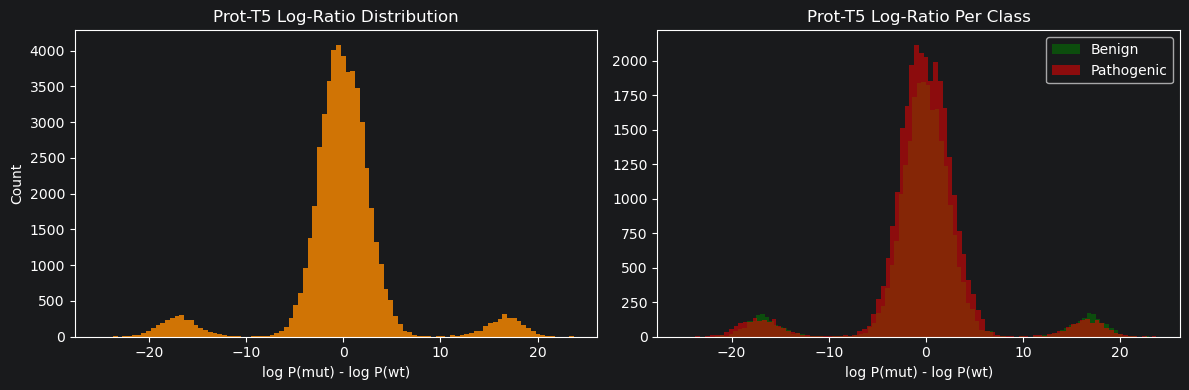

In [13]:
valid_scores = assessable_df.dropna(subset=["prott5_log_ratio"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(valid_scores["prott5_log_ratio"], bins=100, color="darkorange", alpha=0.8)
axes[0].set_title("Prot-T5 Log-Ratio Distribution")
axes[0].set_xlabel("log P(mut) - log P(wt)")
axes[0].set_ylabel("Count")

for label, color, name in [(0, "green", "Benign"), (1, "red", "Pathogenic")]:
    subset = valid_scores[valid_scores["label"] == label]["prott5_log_ratio"]
    axes[1].hist(subset, bins=100, color=color, label=name, alpha=0.5)

axes[1].set_title("Prot-T5 Log-Ratio Per Class")
axes[1].set_xlabel("log P(mut) - log P(wt)")
axes[1].legend()

plt.tight_layout()
plt.show()

In [14]:
print("Statistics per class:")
valid_scores.groupby("label")["prott5_log_ratio"].describe()

Statistics per class:


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,25196.0,0.042248,5.952810,-23.041542,-1.714646,-0.045317,1.697133,22.993029
1,29625.0,-0.196505,5.531997,-25.179392,-1.904331,-0.112854,1.792776,23.706274


## 6. Save final output

In [17]:
output_path = PROCESSED_DATA_DIR / "variants_with_scores.parquet"
assessable_df.to_parquet(output_path, index=False)

print(f"Saved at   : {output_path}")
print(f"Final shape: {assessable_df.shape}")
print(f"Columns    : {list(assessable_df.columns)}")

Saved at   : /Users/dcanevarollo/Desktop/Projetos/Unesp/ia/bio-variant-prediction/data/processed/variants_with_scores.parquet
Final shape: (54821, 18)
Columns    : ['id', 'chrom', 'pos_genomic', 'ref', 'alt', 'gene', 'transcript_id', 'pos_protein', 'aa_wt', 'aa_mut', 'label', 'protein_seq', 'af', 'ac', 'an', 'log_af', 'esm2_log_ratio', 'prott5_log_ratio']
